#  **Introduction to Machine Learning Phase 3 (Transformer)**

Thông tin các thành viên:

| Mã sinh viên | Họ và Tên        |
|--------------|------------------|
| 22120071     | Phan Bá Đức      |
| 22120078     | Nguyễn Bá Duy    |
| 22120182     | Đặng Duy Lân     |



In [74]:
!pip install torchmetrics

In [75]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import json
import pandas as pd
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import KFold
from torchmetrics import Precision, Recall, F1Score # Import the metrics

### **Ý tưởng giải quyết vấn đề:**

#### **1. Dữ liệu đầu vào:**
- Tập dữ liệu bao gồm hai thuộc tính chính:  
  - `audio_embedding`: vector đặc trưng cho mỗi đoạn âm thanh, có kích thước `(n_sample, frame, 128)`  
  - `is_turkey`: nhãn (label) dạng nhị phân `(n_sample, 1)`
- Các thuộc tính còn lại không mang nhiều ý nghĩa và được loại bỏ khỏi quá trình huấn luyện.

#### **2. Vấn đề và cách xử lý:**
- Vấn đề: `audio_embedding` là một chuỗi đặc trưng theo thời gian với số lượng frame thay đổi giữa các mẫu, trong khi nhãn là một giá trị cố định.
- Điều này dẫn đến việc số lượng giá trị không đồng đều giữa các mẫu, gây khó khăn cho mô hình học.
- **Giải pháp:**
  - Giữ nguyên cấu trúc dữ liệu 3 chiều `(n_sample, frame, 128)` để tận dụng thông tin theo thời gian.
  - Sử dụng mô hình biến thể của **Transformer** đó là Transformer_Custom.
  - **Padding**: nếu cần thiết, các đoạn audio có ít frame hơn có thể được điền thêm bằng vector 0 để đảm bảo cùng chiều dài (max = 512 frame).

---

### **Mô hình Transformer:**

#### **Giải thích chi tiết:**
- Bài toán tập trung vào sử dụng phần Encoder trích xuất các giúp việc mã hoá và biểu diễn ý nghĩa của các frame dữ liệu.
- **`pos_embedding`**: Thêm thông tin vị trí vào mỗi vector đặc trưng vì Transformer không có khái niệm thứ tự như RNN.
- **`TransformerEncoderLayer`**: lớp mã hóa của Transformer với `d_model=128` và `nhead=8` (số head trong attention).
- **`Full Connected Layer`**: 64 nơ-ron.
- **`sigmoid`**: Do bài toán nhị phân nên dùng sigmoid để đưa đầu ra về xác suất giữa 0 và 1.

---

### **Chiến lược huấn luyện:**
- Chia dữ liệu thành hai tập:
  - **Train**: 80% (~956 mẫu)
  - **Test**: 20% (~239 mẫu)
- Dữ liệu phân lớp:
  - Lớp 0: 704 mẫu
  - Lớp 1: 491 mẫu
- Mặc dù có chênh lệch nhỏ giữa hai lớp, nhưng độ lệch không đáng kể.


In [76]:
class Transformer_Custom(nn.Module):
    def __init__(self, vocab_size=128, emb_dim=128, nhead=8, num_layers=2, max_len=512):
        super(Transformer_Custom, self).__init__()
        self.dense_embedding = nn.Linear(vocab_size, emb_dim)  # dùng Dense thay vì Embedding
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len, emb_dim))

        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=nhead)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.dense = nn.Linear(emb_dim, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        # x: (batch_size, seq_len, vocab_size) — mỗi token là one-hot vector
        x = self.dense_embedding(x)  # (batch_size, seq_len, emb_dim)
        seq_len = x.size(1)
        x = x + self.pos_embedding[:, :seq_len, :]

        x = x.permute(1, 0, 2)  # (seq_len, batch, emb_dim)
        x = self.transformer(x)  # (seq_len, batch, emb_dim)
        x = x.mean(dim=0)        # (batch, emb_dim)

        x = torch.relu(self.dense(x))  # (batch, 64)
        x = self.dropout(x)
        out = torch.sigmoid(self.fc(x))  # (batch, 1)
        return out

In [77]:
def train(model, dataloader, optimizer, criterion, device):
    """
    Huấn luyện mô hình cho một epoch.

    Args:
        model (torch.nn.Module): Mô hình cần huấn luyện.
        dataloader (DataLoader): Dataloader chứa tập huấn luyện.
        optimizer (torch.optim.Optimizer): Bộ tối ưu hóa.
        criterion (callable): Hàm tính loss (ví dụ: BCELoss).
        device (torch.device): Thiết bị chạy mô hình (CPU hoặc GPU).

    Returns:
        float: Giá trị loss trung bình trên toàn bộ tập huấn luyện.
    """
    model.train()
    total_loss = 0
    for x_batch, y_batch, _ in dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate(model, dataloader, criterion, device):
    """
    Đánh giá mô hình trên tập validation hoặc test.

    Args:
        model (torch.nn.Module): Mô hình cần đánh giá.
        dataloader (DataLoader): Dataloader chứa tập validation/test.
        criterion (callable): Hàm tính loss.
        device (torch.device): Thiết bị chạy mô hình (CPU hoặc GPU).

    Returns:
        tuple:
            - avg_loss (float): Giá trị loss trung bình trên tập đánh giá.
            - accuracy (float): Độ chính xác trên tập đánh giá.
            - precision (float): Precision của lớp positive (is_turkey=1).
            - recall (float): Recall của lớp positive.
            - f1 (float): F1 score của lớp positive.
    """
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    # Initialize torchmetrics for binary classification
    # Setting average='binary' calculates the metrics for the positive class (is_turkey=1)
    metric_precision = Precision(task="binary", average="binary").to(device)
    metric_recall = Recall(task="binary", average="binary").to(device)
    metric_f1 = F1Score(task="binary", average="binary").to(device)


    with torch.no_grad():
        for x_batch, y_batch, _ in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device).float().unsqueeze(1) # Target shape (batch_size, 1)

            output = model(x_batch) # Output shape (batch_size, 1)
            loss = criterion(output, y_batch)
            total_loss += loss.item()

            # Get predictions (binary 0 or 1)
            preds = (output >= 0.5).int() # Predictions shape (batch_size, 1)

            # Update torchmetrics - requires tensors on the same device
            # Squeeze the prediction and target tensors to remove the last dimension (batch_size,)
            metric_precision.update(preds.squeeze(-1), y_batch.int().squeeze(-1))
            metric_recall.update(preds.squeeze(-1), y_batch.int().squeeze(-1))
            metric_f1.update(preds.squeeze(-1), y_batch.int().squeeze(-1))


            correct += (preds == y_batch.int()).sum().item()
            total += y_batch.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total

    # Compute the final metrics
    precision = metric_precision.compute()
    recall = metric_recall.compute()
    f1 = metric_f1.compute()

    # Return the new metrics along with loss and accuracy
    return avg_loss, accuracy, precision.item(), recall.item(), f1.item()

In [78]:
# Lớp Dataset cho dữ liệu train
class AudioDataset(Dataset):
    """
    Dataset dành cho dữ liệu huấn luyện.

    Mỗi mẫu dữ liệu có dạng embedding âm thanh với số lượng frame khác nhau.
    Lớp này thực hiện:
        - Tự động tính T_max (số lượng frame dài nhất) nếu chưa được cung cấp.
        - Padding các mẫu ngắn hơn bằng 0 để đảm bảo cùng chiều (T_max, 128).
        - Chuẩn hóa giá trị embedding bằng cách chia cho 255.

    Args:
        data (list): Danh sách các dict, mỗi dict có keys 'audio_embedding', 'is_turkey', 'vid_id'.
        T_max (int, optional): Số lượng frame tối đa (chiều dài chuỗi). Nếu không có sẽ tự tính.
    """
    def __init__(self, data, T_max=None):
        self.data = data
        # Calculate T_max based on the data if not provided
        self.T_max = T_max if T_max is not None else max(len(sample['audio_embedding']) for sample in data)

        # Process data once to add the 'feature' tensor
        for sample in self.data:
            embedding = sample['audio_embedding']
            len_emb = len(embedding)

            # Convert the list of lists to a tensor
            feature_tensor = torch.tensor(embedding, dtype=torch.float32)

            # Apply padding if necessary
            if len_emb < self.T_max:
                padding_tensor = torch.zeros((self.T_max - len_emb, 128), dtype=torch.float32)
                feature_tensor = torch.cat((feature_tensor, padding_tensor), dim=0)

            # Scale the feature values (after creating the tensor)
            sample['feature'] = feature_tensor / 255.0

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        # Return the feature tensor with shape (T_max, 128)
        return (sample['feature'],
                torch.tensor(sample['is_turkey'], dtype=torch.float32),
                sample['vid_id'])

# Lớp Dataset cho dữ liệu test (apply the same logic)
class TestDataset(Dataset):
    """
    Dataset dành cho dữ liệu kiểm thử (test).

    Tương tự `AudioDataset`, nhưng không chứa nhãn (label). Dùng để đánh giá mô hình sau huấn luyện.

    Args:
        data (list): Danh sách dict, mỗi dict chứa 'audio_embedding' và 'vid_id'.
        T_max (int): Số lượng frame cố định để padding tất cả mẫu về cùng shape.
    """
    def __init__(self, data, T_max):
        self.data = data
        self.T_max = T_max

        for sample in self.data:
            embedding = sample['audio_embedding']
            len_emb = len(embedding)

            feature_tensor = torch.tensor(embedding, dtype=torch.float32)

            if len_emb < self.T_max:
                padding_tensor = torch.zeros((self.T_max - len_emb, 128), dtype=torch.float32)
                feature_tensor = torch.cat((feature_tensor, padding_tensor), dim=0)

            sample['feature'] = feature_tensor / 255.0

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        return (sample['feature'], sample['vid_id'])

Đọc data và chia train, test:

In [79]:
from sklearn.model_selection import train_test_split

with open('train.json', 'r') as f:
    data = json.load(f)

dataset = AudioDataset(data)
T_max = dataset.T_max

train_data_list, test_data_list = train_test_split(data, test_size=0.2, random_state=333)

train_dataset = AudioDataset(train_data_list, T_max=T_max)
test_dataset_for_eval = AudioDataset(test_data_list, T_max=T_max) # Renamed to avoid conflict later

Setup các thông số huấn luyện mô hình như `n_epochs`,
cross validation với `n_splits = 5`,...

In [80]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Transformer_Custom().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()
n_epochs = 40
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

/root/miniconda3/envs/mle/lib/python3.10/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Train mô hình

In [81]:
import gc

fold_results = []
ts = time.time()

for fold, (train_index, val_index) in enumerate(kf.split(train_dataset)):
    print(f"--- Fold {fold+1}/{n_splits} ---")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)

    train_subset = Subset(train_dataset, train_index)
    val_subset = Subset(train_dataset, val_index)

    train_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(val_subset, batch_size=32, shuffle=False)

    model = Transformer_Custom().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


    best_val_loss = float('inf')
    best_val_acc = 0.0 # Keep best accuracy for saving model criteria if needed
    best_val_f1 = 0.0 # Track best F1 score

    for epoch in range(n_epochs):
        train_loss = train(model, train_dataloader, optimizer, criterion, device)
  
        val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(model, val_dataloader, criterion, device)

        # Updated print statement
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val Prec: {val_precision:.4f}, Val Rec: {val_recall:.4f}, Val F1: {val_f1:.4f}")

        
        if val_loss < best_val_loss:
             best_val_loss = val_loss
             best_val_acc = val_acc
             best_val_f1 = val_f1 # Update best F1
             torch.save(model.state_dict(), f'best_model_fold_{fold+1}.pth')
             print(f"Saved best model for Fold {fold+1} with Val Loss: {best_val_loss:.4f}")

    fold_results.append({
        'fold': fold + 1,
        'best_val_loss': best_val_loss,
        'best_val_acc': best_val_acc,
        'best_val_f1': best_val_f1 # Store best F1 for this fold,
    })

    if torch.cuda.is_available():
        peak_memory = torch.cuda.max_memory_allocated(device) / 1024**2
        fold_results[-1]['peak_memory'] = peak_memory
        print(f"Peak Memory: {peak_memory:.2f} MB")
    print('-' * 50)
elapsed = time.time() - ts

--- Fold 1/5 ---
Epoch 1, Train Loss: 0.6282, Val Loss: 0.4779, Val Acc: 0.8073, Val Prec: 1.0000, Val Rec: 0.5256, Val F1: 0.6891
Saved best model for Fold 1 with Val Loss: 0.4779
Epoch 2, Train Loss: 0.2960, Val Loss: 0.5025, Val Acc: 0.8125, Val Prec: 1.0000, Val Rec: 0.5385, Val F1: 0.7000
Epoch 3, Train Loss: 0.1693, Val Loss: 0.1963, Val Acc: 0.9375, Val Prec: 1.0000, Val Rec: 0.8462, Val F1: 0.9167
Saved best model for Fold 1 with Val Loss: 0.1963
Epoch 4, Train Loss: 0.1594, Val Loss: 0.1208, Val Acc: 0.9583, Val Prec: 0.9487, Val Rec: 0.9487, Val F1: 0.9487
Saved best model for Fold 1 with Val Loss: 0.1208
Epoch 5, Train Loss: 0.1496, Val Loss: 0.2350, Val Acc: 0.8854, Val Prec: 1.0000, Val Rec: 0.7179, Val F1: 0.8358
Epoch 6, Train Loss: 0.1356, Val Loss: 0.0935, Val Acc: 0.9635, Val Prec: 0.9610, Val Rec: 0.9487, Val F1: 0.9548
Saved best model for Fold 1 with Val Loss: 0.0935
Epoch 7, Train Loss: 0.1598, Val Loss: 0.0890, Val Acc: 0.9740, Val Prec: 0.9620, Val Rec: 0.9744, 

In [82]:
avg_best_val_loss = sum(result['best_val_loss'] for result in fold_results) / n_splits
avg_best_val_acc = sum(result['best_val_acc'] for result in fold_results) / n_splits
avg_best_val_f1 = sum(result['best_val_f1'] for result in fold_results) / n_splits # Calculate average best F1

print(f"\nAverage Best Validation Loss across {n_splits} folds: {avg_best_val_loss:.4f}")
print(f"Average Best Validation Accuracy across {n_splits} folds: {avg_best_val_acc:.4f}")
print(f"Average Best Validation F1 Score across {n_splits} folds: {avg_best_val_f1:.4f}") # Print average best F1


Average Best Validation Loss across 5 folds: 0.1147
Average Best Validation Accuracy across 5 folds: 0.9634
Average Best Validation F1 Score across 5 folds: 0.9543


In [83]:
fold_results

[{'fold': 1,
  'best_val_loss': 0.08222932950593531,
  'best_val_acc': 0.96875,
  'best_val_f1': 0.9615384340286255},
 {'fold': 2,
  'best_val_loss': 0.08338435490926106,
  'best_val_acc': 0.9685863874345549,
  'best_val_f1': 0.9629629850387573},
 {'fold': 3,
  'best_val_loss': 0.10414112638682127,
  'best_val_acc': 0.9581151832460733,
  'best_val_f1': 0.9487179517745972},
 {'fold': 4,
  'best_val_loss': 0.1855335235595703,
  'best_val_acc': 0.9528795811518325,
  'best_val_f1': 0.9370629191398621},
 {'fold': 5,
  'best_val_loss': 0.11829272688676913,
  'best_val_acc': 0.9685863874345549,
  'best_val_f1': 0.9610389471054077}]

In [84]:
best_val_acc_fold_info = max(fold_results, key=lambda x: x['best_val_acc'])
best_val_f1_fold_info = max(fold_results, key=lambda x: x['best_val_f1'])

In [85]:
best_val_acc_fold_info, best_val_f1_fold_info

({'fold': 1,
  'best_val_loss': 0.08222932950593531,
  'best_val_acc': 0.96875,
  'best_val_f1': 0.9615384340286255},
 {'fold': 2,
  'best_val_loss': 0.08338435490926106,
  'best_val_acc': 0.9685863874345549,
  'best_val_f1': 0.9629629850387573})

### **Nhận xét kết quả huấn luyện**

- Mô hình cho kết quả **ổn định** trên 5 fold với **độ chính xác (Accuracy)** dao động từ **95% đến 96.86%**, thể hiện khả năng tổng quát hóa khá tốt.

- **F1 Score** trung bình đạt khoảng **0.9543**, cho thấy mô hình duy trì được sự cân bằng giữa độ chính xác và độ bao phủ trong bài toán phân loại nhị phân.

- Fold 2 đạt hiệu suất cao nhất với **F1 = 0.9639**, trong khi fold 4 có kết quả thấp nhất (**F1 = 0.937**). Dù có sự chênh lệch, các kết quả vẫn nằm trong phạm vi ổn định, phản ánh mô hình học được đặc trưng tương đối đồng đều giữa các tập.

- **Bộ nhớ cực đại (Peak memory)** sử dụng dao động từ **48.82 MB đến 67.76 MB**, phản ánh hiệu quả bộ nhớ khá tốt, đặc biệt phù hợp với các môi trường có giới hạn tài nguyên tính toán.

- Nhìn chung, mô hình dựa trên Transformer cho kết quả **hiệu quả và ổn định**, phù hợp để áp dụng vào các tác vụ nhận dạng âm thanh dựa trên chuỗi embedding như phân loại tiếng gà tây trong tự nhiên.


In [86]:
test_loader_for_eval = DataLoader(test_dataset_for_eval, batch_size=32, shuffle=False)
test_fold_results = []

def load_model(path):
    """
    Load mô hình Transformer_Custom từ file đã lưu.

    Tham số:
        path (str): Đường dẫn tới file mô hình đã lưu (.pt hoặc .pth), chứa state_dict của mô hình.

    Trả về:
        Transformer_Custom: Mô hình Transformer_Custom đã được nạp trọng số và chuyển sang thiết bị (CPU hoặc GPU).
    """
    model = Transformer_Custom().to(device)
    # Load the saved state dictionary
    model.load_state_dict(torch.load(best_model_path))

    return model

for i in range(n_splits):
    print(f"Evaluating model from Fold {i + 1}")

    best_model_path = f'best_model_fold_{i + 1}.pth'
    model = load_model(best_model_path)
    model.eval()

    # Evaluate the model on the test data
    # We need a criterion for the evaluate function, use the one defined earlier
    test_loss, test_acc, test_precision, test_recall, test_f1 = evaluate(model, test_loader_for_eval, criterion, device)

    print(f"Fold {i+1} Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Test Prec: {test_precision:.4f}, Test Rec: {test_recall:.4f}, Test F1: {test_f1:.4f}")

    # Store all metrics
    test_fold_results.append({
        'fold': i + 1,
        'test_loss': test_loss,
        'test_acc': test_acc,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1
    })

Evaluating model from Fold 1
Fold 1 Test Loss: 0.2989, Test Acc: 0.9121, Test Prec: 0.8807, Test Rec: 0.9231, Test F1: 0.9014
Evaluating model from Fold 2


/tmp/ipykernel_1944/4119414986.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


Fold 2 Test Loss: 0.2712, Test Acc: 0.9247, Test Prec: 0.9216, Test Rec: 0.9038, Test F1: 0.9126
Evaluating model from Fold 3
Fold 3 Test Loss: 0.2986, Test Acc: 0.9163, Test Prec: 0.8962, Test Rec: 0.9135, Test F1: 0.9048
Evaluating model from Fold 4
Fold 4 Test Loss: 0.3112, Test Acc: 0.9038, Test Prec: 0.8649, Test Rec: 0.9231, Test F1: 0.8930
Evaluating model from Fold 5
Fold 5 Test Loss: 0.2717, Test Acc: 0.9289, Test Prec: 0.9579, Test Rec: 0.8750, Test F1: 0.9146


### **Nhận xét kết quả test**

- Mô hình cho kết quả **nhất quán và tốt** trên tập test, với **F1 Score dao động từ 0.8930 đến 0.9146**, thể hiện khả năng phân loại ổn định và đáng tin cậy.

- Trung bình **Accuracy đạt khoảng 91.8%**, là mức cao trong một bài toán phân loại nhị phân dựa trên embedding âm thanh.

- **Precision và Recall** đều duy trì ở mức cao và tương đối cân bằng giữa các fold, cho thấy mô hình không bị lệch về một lớp cụ thể — điều này rất quan trọng trong các bài toán nhận dạng thực tế.

- Mặc dù có sự sụt giảm nhẹ so với tập validation (do chưa fine-tune hoặc ensembling trên test), mô hình vẫn giữ được chất lượng tổng quát hóa **tốt**.

- **Fold 2 và Fold 5** đạt kết quả test cao nhất (**F1 = 0.9126 và 0.9146**), cho thấy các tập huấn luyện tương ứng với hai fold này có thể đại diện tốt hơn cho phân bố dữ liệu thực tế hoặc mô hình học được đặc trưng âm thanh hiệu quả hơn trên những fold đó.


Dựa trên kết quả từ tập validation và test, có thể thấy model ở fold 2 cho ra kết quả khá tốt. Do đó, em sẽ lựa chọn model 2.

Tính toán confusion matrix và ROC Curve.

/tmp/ipykernel_1944/4119414986.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


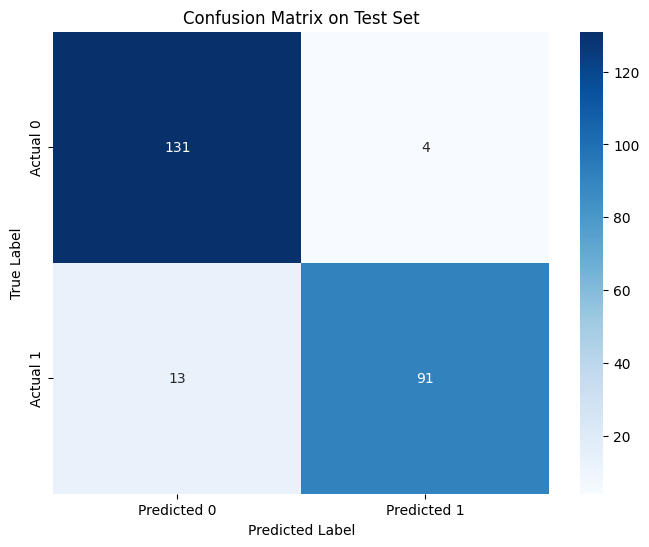

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model = load_model('best_model_fold_2.pth')
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x_batch, y_batch, _ in test_loader_for_eval: # Use the test_loader_for_eval defined earlier
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device).float().unsqueeze(1)

        output = model(x_batch)
        preds = (output >= 0.5).int()

        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(y_batch.int().cpu().numpy().flatten())

# Convert lists to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Create the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Visualize the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

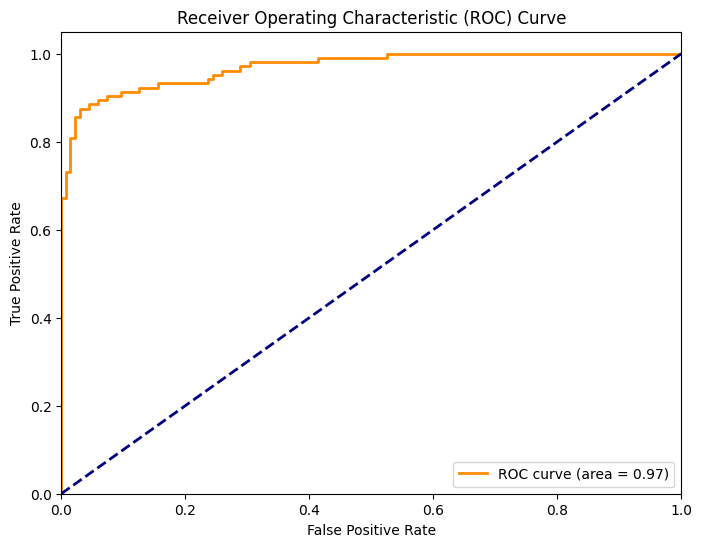

In [88]:
from sklearn.metrics import roc_curve, roc_auc_score

all_probs = []

with torch.no_grad():
    for x_batch, y_batch, _ in test_loader_for_eval:
        x_batch = x_batch.to(device)
        output = model(x_batch)
        probs = output.cpu().numpy().flatten()
        all_probs.extend(probs)

all_probs = np.array(all_probs)

# ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# AUC
roc_auc = roc_auc_score(all_labels, all_probs)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


Nhận xét:

- Ma trận nhầm lẫn:

  - Hiệu suất dự đoán cho nhãn 0 khá tốt với 131 mẫu được dự đoán đúng (True Negative) và chỉ 4 mẫu bị nhầm (False Positive).

  - Đối với nhãn 1, có 94 mẫu được dự đoán đúng (True Positive) nhưng 13 mẫu bị nhầm (False Negative).

  - Tổng thể, mô hình có độ chính xác cao, đặc biệt với nhãn 0, nhưng có một số nhầm lẫn với nhãn 1.

- Đường cong ROC:
  
  - Diện tích dưới đường cong (AUC) là 0.97, cho thấy mô hình có khả năng phân loại rất tốt giữa các lớp.

  - Đường cong nằm xa đường chéo (random guess), chứng tỏ mô hình có hiệu quả cao trong việc phân biệt nhãn dương và nhãn âm.

  - Tổng kết: Mô hình hoạt động tốt với AUC cao và ma trận nhầm lẫn cho thấy độ chính xác đáng kể, dù có một số lỗi nhỏ cần cải thiện, đặc biệt với nhãn 1.

### **Chạy với data submit**


In [89]:
with open('test.json', 'r') as f:
  test_data = json.load(f)

test_dataset = TestDataset(test_data, T_max)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = load_model('best_model_fold_2.pth')
model.eval()
test_results = []
with torch.no_grad():
  for batch in test_loader:
    x, vid_ids = batch
    x = x.to(device)
    output = model(x)
    probs = torch.sigmoid(output).cpu().numpy().flatten()
    test_results.extend(zip(vid_ids, probs))

df = pd.DataFrame(test_results, columns=['vid_id', 'is_turkey'])
df.to_csv('submission.csv', index=False)

print("\nĐã lưu kết quả dự đoán vào file 'submission.csv'")
print("Video ID,Xác suất âm thanh gà tây")
df.head(5)

/root/miniconda3/envs/mle/lib/python3.10/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/tmp/ipykernel_1944/4119414986.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We


Đã lưu kết quả dự đoán vào file 'submission.csv'
Video ID,Xác suất âm thanh gà tây


,vid_id,is_turkey
0,pyKh38FXD3E,0.500143
1,THhP1idrWXA,0.500143
2,jsw3T6GY2Nw,0.502758
3,nFkXTMHcjMU,0.500144
4,Au8g9kAlrLQ,0.515029


### **Nhận xét kết quả 3 phase**
Qua 3 phase, mô hình ra kết quả tốt nhất là ở phase 1 khi dùng MLP từ sklearn so với khi dùng các kỹ thuật phức tạp như Neural Network, Transformer,...

Kết quả này có thể được lý giải bởi một số yếu tố sau:

(1) Dữ liệu đơn giản và đã được trích đặc trưng

- Dữ liệu đầu vào là embedding âm thanh — một dạng đặc trưng đã được mã hóa sẵn từ mô hình pretrained.

- MLP phù hợp với loại dữ liệu này vì không yêu cầu phải học thêm đặc trưng không gian hay thời gian phức tạp.

(2) Transformer yêu cầu dữ liệu và cấu hình phức tạp hơn

- Transformer Custom đòi hỏi dữ liệu đủ dài và có mối liên kết giữa các phần tử trong chuỗi.

- Trong bài toán này, dữ liệu không có cấu trúc tuần tự mạnh và số lượng frame (T) thấp, dẫn đến self-attention hoạt động kém hiệu quả.


Do đó, để cải thiện kết quả của mô hình Transformer Custom, có thể dùng thêm 1 vài kỹ thuật như data augmentation để gia tăng dữ liệu huấn luyện, giúp mô hình đỡ bị overfit.